PROPÓSITO DEL ANÁLISIS ESPACIOTEMPORAL
Pregunta Principal de Investigación:
¿Cómo se manifestó geográfica y temporalmente el impacto de la inteligencia artificial en el mercado laboral tech global entre 2020-2025?

OBJETIVOS ESPECÍFICOS:
1. TEMPORAL:

cómo evolucionaron los salarios tech globalmente con el impacto de la IA, midiendo la magnitud del cambio Pre-IA vs Post-IA, detectando patrones predecibles mediante ACF y Random Walk, y comparando la evolución entre países. Usamos el dataset balanceado porque con el original USA (58,909 registros) dominaría completamente el análisis y solo veríamos patrones de USA, mientras que con el balanceo todos los países tienen peso similar y podemos observar cambios globales reales y hacer comparaciones justas. La única excepción es el Proportional Symbol Map que usa el dataset original porque su objetivo específico es mostrar la concentración geográfica real de empleos (dónde están físicamente), no comparar cambios temporales.

2. ESPACIAL:

¿Dónde están las oportunidades y cómo se distribuyen globalmente?Propósito:
Identificar mercados emergentes vs saturados
Mapear zonas de alta demanda (choropleth de densidad)
Detectar crecimiento diferenciado (¿qué países crecen más rápido?)
Visualizar flujos de talento (¿hacia dónde migran los profesionales?)
Calcular impacto económico por región

3. ESPACIOTEMPORAL (INTEGRACIÓN):

Detectar si existe un patrón de "difusión geográfica" del impacto IA (¿qué países fueron early adopters?)
Analizar si el crecimiento en una región predice crecimiento en regiones vecinas (lead/lag)
Determinar si hay correlación entre proximidad geográfica y similitud en evolución salarial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'])

def classify_ai_period(year):
    if year <= 2022:
        return 'Pre-IA (2020-2022)'
    else:
        return 'Post-IA (2023-2025)'

df['ai_period'] = df['work_year'].apply(classify_ai_period)

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"\nPeriodos de IA:\n{df['ai_period'].value_counts().sort_index()}")
print(f"\nAnos disponibles: {sorted(df['work_year'].unique())}")

Dataset cargado exitosamente
Dimensiones: (65117, 23)

Periodos de IA:
ai_period
Post-IA (2023-2025)    62840
Pre-IA (2020-2022)      2277
Name: count, dtype: int64

Anos disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [4]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,...,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name,created_at,updated_at,ai_period
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,0,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:09.747369,2025-10-26T02:25:09.747369,Pre-IA (2020-2022)
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,100,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,50,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,100,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,0,US,...,Executive & Leadership,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)


### AGREGAR RUIDO ARTIFICIAL - DIVIDIR POR CUATRIMESTRE

In [5]:
print("="*70)
print("PREPARACION DE DATOS - AGREGANDO GRANULARIDAD TEMPORAL")
print("="*70)

# Asignar cuatrimestre aleatorio a cada registro
np.random.seed(42)
df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))

# Crear fecha artificial: año + cuatrimestre
# Cuatrimestre 1: Enero-Abril (mes 2)
# Cuatrimestre 2: Mayo-Agosto (mes 6)  
# Cuatrimestre 3: Septiembre-Diciembre (mes 10)
cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
df['fecha_artificial'] = pd.to_datetime(
    df['work_year'].astype(str) + '-' + df['mes_artificial'].astype(str) + '-01'
)

print(f"Registros totales: {len(df):,}")
print(f"Rango temporal original: {df['work_year'].min()} - {df['work_year'].max()}")
print(f"Rango temporal con cuatrimestres: {df['fecha_artificial'].min()} - {df['fecha_artificial'].max()}")
print(f"Observaciones temporales: {df['fecha_artificial'].nunique()} (año-cuatrimestre)")

PREPARACION DE DATOS - AGREGANDO GRANULARIDAD TEMPORAL
Registros totales: 65,117
Rango temporal original: 2020 - 2025
Rango temporal con cuatrimestres: 2020-02-01 00:00:00 - 2025-10-01 00:00:00
Observaciones temporales: 18 (año-cuatrimestre)


### BALANCEAR DATOS DE USA vs OTROS PAISES

In [6]:
print("\n" + "="*70)
print("BALANCEO DE DATOS POR PAIS")
print("="*70)

# Contar empleos por pais
country_counts = df['employee_country_name'].value_counts()
print("\nTop 10 paises por volumen:")
print(country_counts.head(10))

# Identificar USA (o el pais con mas datos)
dominant_country = country_counts.index[0]
dominant_count = country_counts.iloc[0]

print(f"\nPais dominante: {dominant_country} con {dominant_count:,} registros")

# Calcular mediana de empleos (excluyendo el pais dominante)
other_countries_median = country_counts[1:].median()
print(f"Mediana de otros paises: {other_countries_median:.0f} registros")

# Submuestrear el pais dominante para balancear
df_dominant = df[df['employee_country_name'] == dominant_country]
df_others = df[df['employee_country_name'] != dominant_country]

# Sample del pais dominante (3x la mediana para mantener representatividad)
target_sample_size = min(int(other_countries_median * 3), len(df_dominant))
df_dominant_sampled = df_dominant.sample(n=target_sample_size, random_state=42)

# Combinar datos balanceados
df_balanced = pd.concat([df_dominant_sampled, df_others], ignore_index=True)

print(f"\nDataset balanceado:")
print(f"  {dominant_country}: {len(df_dominant_sampled):,} registros (reducido de {len(df_dominant):,})")
print(f"  Otros paises: {len(df_others):,} registros")
print(f"  Total: {len(df_balanced):,} registros")

# Usar dataset balanceado para el resto del analisis
df = df_balanced.copy()

print("\n" + "="*70)
print("Dataset cargado y preparado exitosamente")
print("="*70)
print(f"Dimensiones: {df.shape}")
print(f"\nPeriodos de IA:\n{df['ai_period'].value_counts().sort_index()}")


BALANCEO DE DATOS POR PAIS

Top 10 paises por volumen:
employee_country_name
Estados Unidos    58909
Canadá             2132
Reino Unido        1353
Alemania            479
Países Bajos        303
Australia           298
Austria             169
Eslovaquia          147
Francia             121
India                96
Name: count, dtype: int64

Pais dominante: Estados Unidos con 58,909 registros
Mediana de otros paises: 6 registros

Dataset balanceado:
  Estados Unidos: 18 registros (reducido de 58,909)
  Otros paises: 6,208 registros
  Total: 6,226 registros

Dataset cargado y preparado exitosamente
Dimensiones: (6226, 26)

Periodos de IA:
ai_period
Post-IA (2023-2025)    5491
Pre-IA (2020-2022)      735
Name: count, dtype: int64


### CREAR SERIES TEMPORALES APILADAS POR PAIS

In [7]:
# Asegurarse de que exista 'fecha_artificial' en df (si no, recrearla como en la preparación de datos)
if 'fecha_artificial' not in df.columns or df['fecha_artificial'].isnull().all():
    # Crear cuatrimestre si no existe
    if 'cuatrimestre' not in df.columns:
        np.random.seed(42)
        df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))
    cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
    df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
    # Asegurar que work_year es numérico
    df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
    df['fecha_artificial'] = pd.to_datetime(
        df['work_year'].astype(int).astype(str) + '-' + df['mes_artificial'].astype(str) + '-01',
        errors='coerce'
    )

# Seleccionar paises con datos balanceados (minimo 100 registros)
country_counts = df['employee_country_name'].value_counts()
top_countries = country_counts[country_counts >= 100].index.tolist()
df_top = df[df['employee_country_name'].isin(top_countries)].copy()

# Crear series temporales por pais usando fecha artificial (cuatrimestres)
country_quarter_salary = df_top.groupby(['employee_country_name', 'fecha_artificial']).agg({
    'salary_in_usd': ['mean', 'count']
}).reset_index()

country_quarter_salary.columns = ['country', 'date', 'mean_salary', 'count']

# Filtrar paises con datos en al menos la mitad de los cuatrimestres disponibles
quarters_available = df['fecha_artificial'].nunique()
min_quarters = max(6, quarters_available // 2)
country_counts_quarters = country_quarter_salary.groupby('country')['date'].count()
valid_countries = country_counts_quarters[country_counts_quarters >= min_quarters].index.tolist()
country_quarter_salary = country_quarter_salary[country_quarter_salary['country'].isin(valid_countries)]

print(f"\nPaises con 100+ registros: {len(top_countries)}")
print(f"Paises con datos en {min_quarters}+ cuatrimestres: {len(valid_countries)}")
print(f"Total de observaciones pais-cuatrimestre: {len(country_quarter_salary)}")

# Calcular retornos por pais
country_quarter_salary = country_quarter_salary.sort_values(['country', 'date'])
country_quarter_salary['returns'] = country_quarter_salary.groupby('country')['mean_salary'].pct_change() * 100

# Serie apilada para ACF
stacked_returns = country_quarter_salary['returns'].dropna()

print(f"Observaciones para ACF (series apiladas por cuatrimestre): {len(stacked_returns)}")



Paises con 100+ registros: 8
Paises con datos en 9+ cuatrimestres: 7
Total de observaciones pais-cuatrimestre: 118
Observaciones para ACF (series apiladas por cuatrimestre): 111


### SERIES TEMPORALES AGREGADAS GLOBALES

In [8]:
quarterly_metrics = df.groupby('fecha_artificial').agg({
    'salary_in_usd': ['mean', 'median', 'count'],
    'employee_country_name': 'nunique'
}).reset_index()

quarterly_metrics.columns = ['date', 'mean_salary', 'median_salary', 'job_count', 'country_count']

# Calcular proporciones por cuatrimestre
exp_level_quarter = df.groupby(['fecha_artificial', 'experience_level']).size().unstack(fill_value=0)
exp_level_quarter_pct = exp_level_quarter.div(exp_level_quarter.sum(axis=1), axis=0) * 100

category_quarter = df.groupby(['fecha_artificial', 'category']).size().reset_index(name='count')

print("\nMetricas cuatrimestrales globales:")
print(quarterly_metrics.head(10))


Metricas cuatrimestrales globales:
        date    mean_salary  median_salary  job_count  country_count
0 2020-02-01   84160.875000        62726.0         40             20
1 2020-06-01   72871.394737        66432.5         38             22
2 2020-10-01   77712.368421        67287.5         38             21
3 2021-02-01   73753.932039        68342.0        103             37
4 2021-06-01   69137.830189        61043.0        106             33
5 2021-10-01   75515.819277        65000.0         83             27
6 2022-02-01   91807.560345        74440.0        116             29
7 2022-06-01   83374.254902        73880.0        102             26
8 2022-10-01   93955.330275        78800.0        109             29
9 2023-02-01  103981.877778        89327.0         90             24


### VISUALIZACION: LINE GRAPHS (4 metricas clave)

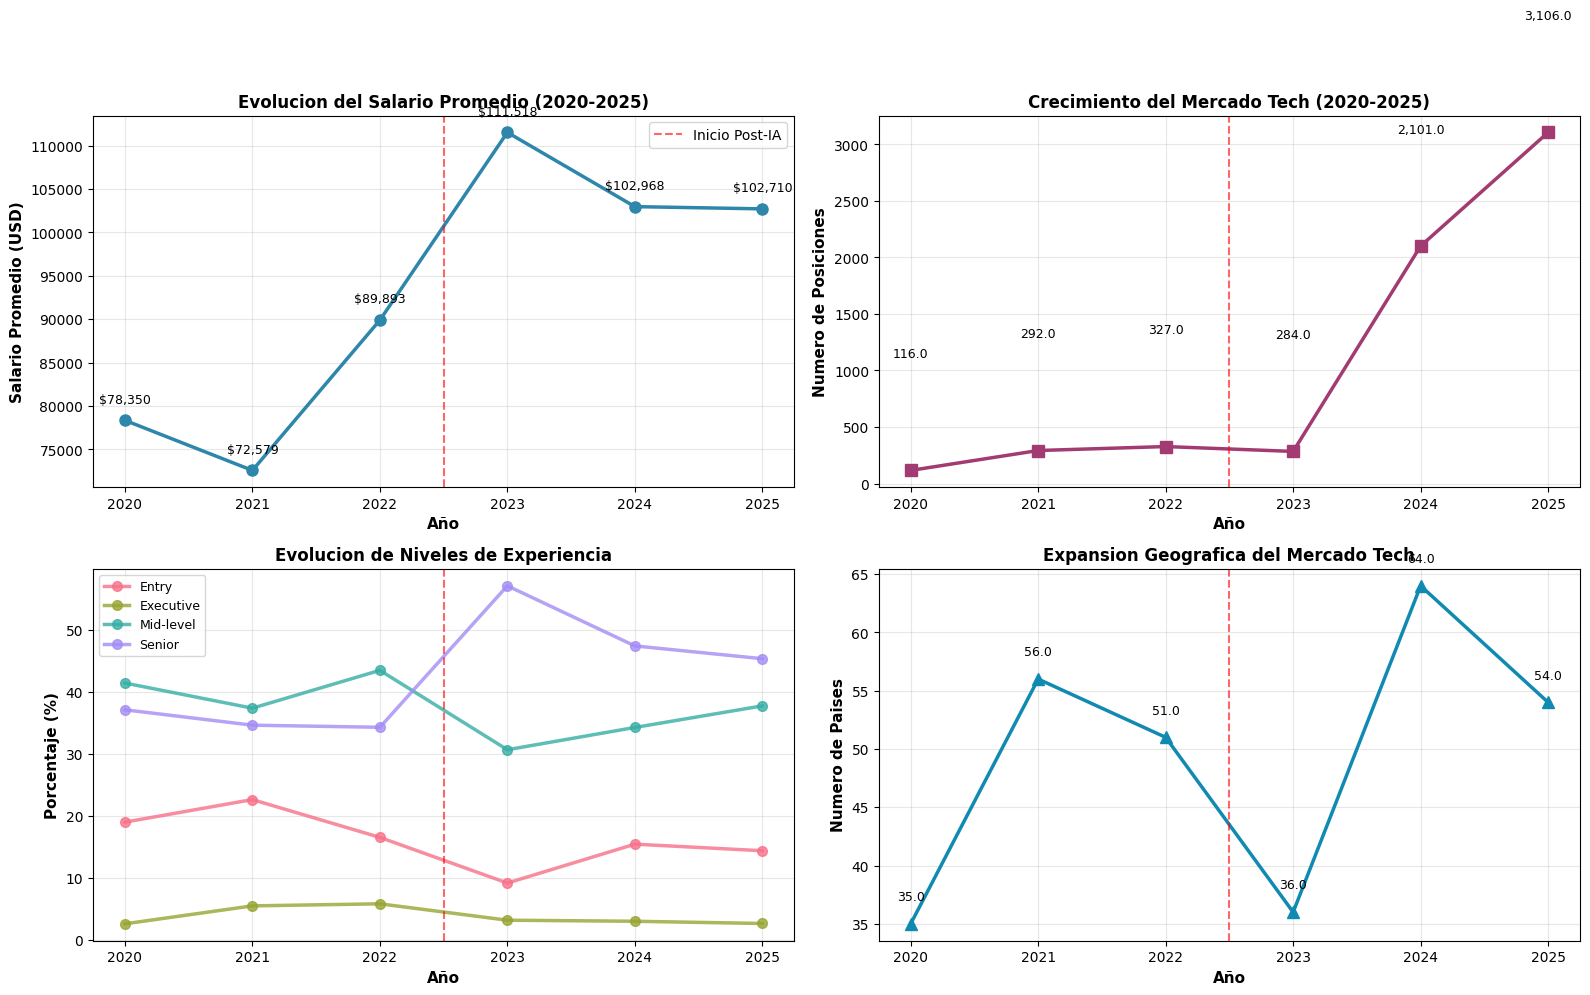

In [9]:
# Asegurar que 'yearly_metrics' exista: crear a partir de df si no está definido
if 'yearly_metrics' not in globals():
    yearly_metrics = (
        df.groupby('work_year')
          .agg(mean_salary=('salary_in_usd', 'mean'),
               median_salary=('salary_in_usd', 'median'),
               job_count=('salary_in_usd', 'count'),
               country_count=('employee_country_name', 'nunique'))
          .reset_index()
          .rename(columns={'work_year': 'year'})
          .sort_values('year')
          .reset_index(drop=True)
    )

# Asegurar que 'exp_level_year_pct' exista: crear a partir de df si no está definido
if 'exp_level_year_pct' not in globals():
    exp_level_year = df.groupby(['work_year', 'experience_level']).size().unstack(fill_value=0)
    exp_level_year_pct = exp_level_year.div(exp_level_year.sum(axis=1), axis=0) * 100
    exp_level_year_pct.index.name = 'work_year'
    # Si se prefiere índice como enteros de año
    try:
        exp_level_year_pct.index = exp_level_year_pct.index.astype(int)
    except Exception:
        pass

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 3.1 Salario promedio
axes[0, 0].plot(yearly_metrics['year'], yearly_metrics['mean_salary'], 
                marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6, label='Inicio Post-IA')
axes[0, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Salario Promedio (USD)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Evolucion del Salario Promedio (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 0].text(row['year'], row['mean_salary'] + 2000, f"${row['mean_salary']:,.0f}", 
                    ha='center', fontsize=9)

# 3.2 Numero de empleos tech
axes[0, 1].plot(yearly_metrics['year'], yearly_metrics['job_count'], 
                marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[0, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[0, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Numero de Posiciones', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Crecimiento del Mercado Tech (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 1].text(row['year'], row['job_count'] + 1000, f"{row['job_count']:,}", 
                    ha='center', fontsize=9)

# 3.3 Proporcion de niveles de experiencia (todos los disponibles)
exp_levels = exp_level_year_pct.columns.tolist()
colors = sns.color_palette("husl", len(exp_levels))
exp_level_map = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

for i, level in enumerate(exp_levels):
    label = exp_level_map.get(level, level)
    axes[1, 0].plot(exp_level_year_pct.index, exp_level_year_pct[level], 
                    marker='o', linewidth=2.5, markersize=7, 
                    color=colors[i], label=label, alpha=0.8)

axes[1, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Porcentaje (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Evolucion de Niveles de Experiencia', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 3.4 Numero de paises activos
axes[1, 1].plot(yearly_metrics['year'], yearly_metrics['country_count'], 
                marker='^', linewidth=2.5, markersize=8, color='#118AB2')
axes[1, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Numero de Paises', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Expansion Geografica del Mercado Tech', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[1, 1].text(row['year'], row['country_count'] + 2, f"{row['country_count']}", 
                    ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### TEST DE RANDOM WALK EN SERIES APILADAS

In [10]:
print("\n" + "="*70)
print("TEST DE RANDOM WALK - SERIES APILADAS POR PAIS")
print("="*70)

# Test en salarios apilados (niveles) - CUATRIMESTRAL
stacked_salaries = country_quarter_salary['mean_salary'].dropna()
adf_salary = adfuller(stacked_salaries, autolag='AIC')

print(f"\n4.1 TEST EN SALARIOS (series apiladas por cuatrimestre - {len(stacked_salaries)} obs):")
print(f"ADF Statistic: {adf_salary[0]:.4f}")
print(f"p-value: {adf_salary[1]:.4f}")
print(f"Lags usados: {adf_salary[2]}")
print(f"Numero de observaciones: {adf_salary[3]}")
print("\nValores criticos:")
for key, value in adf_salary[4].items():
    print(f"  {key}: {value:.4f}")

if adf_salary[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los salarios siguen un RANDOM WALK")
    print("Serie NO estacionaria - tendencia temporal presente")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk")
    print("Serie estacionaria")

# Test en retornos apilados
adf_returns = adfuller(stacked_returns, autolag='AIC')

print(f"\n4.2 TEST EN RETORNOS (series apiladas por cuatrimestre - {len(stacked_returns)} obs):")
print(f"ADF Statistic: {adf_returns[0]:.4f}")
print(f"p-value: {adf_returns[1]:.4f}")
print(f"Lags usados: {adf_returns[2]}")
print(f"Numero de observaciones: {adf_returns[3]}")
print("\nValores criticos:")
for key, value in adf_returns[4].items():
    print(f"  {key}: {value:.4f}")

if adf_returns[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los retornos siguen un random walk")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS")
    print("No hay autocorrelacion significativa - variaciones son aleatorias")



TEST DE RANDOM WALK - SERIES APILADAS POR PAIS

4.1 TEST EN SALARIOS (series apiladas por cuatrimestre - 118 obs):
ADF Statistic: -2.9814
p-value: 0.0367
Lags usados: 7
Numero de observaciones: 110

Valores criticos:
  1%: -3.4912
  5%: -2.8882
  10%: -2.5810

CONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk
Serie estacionaria

4.2 TEST EN RETORNOS (series apiladas por cuatrimestre - 111 obs):
ADF Statistic: -17.5960
p-value: 0.0000
Lags usados: 0
Numero de observaciones: 110

Valores criticos:
  1%: -3.4912
  5%: -2.8882
  10%: -2.5810

CONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS
No hay autocorrelacion significativa - variaciones son aleatorias


### ANALISIS DE AUTOCORRELACION (ACF) - SERIES APILADAS

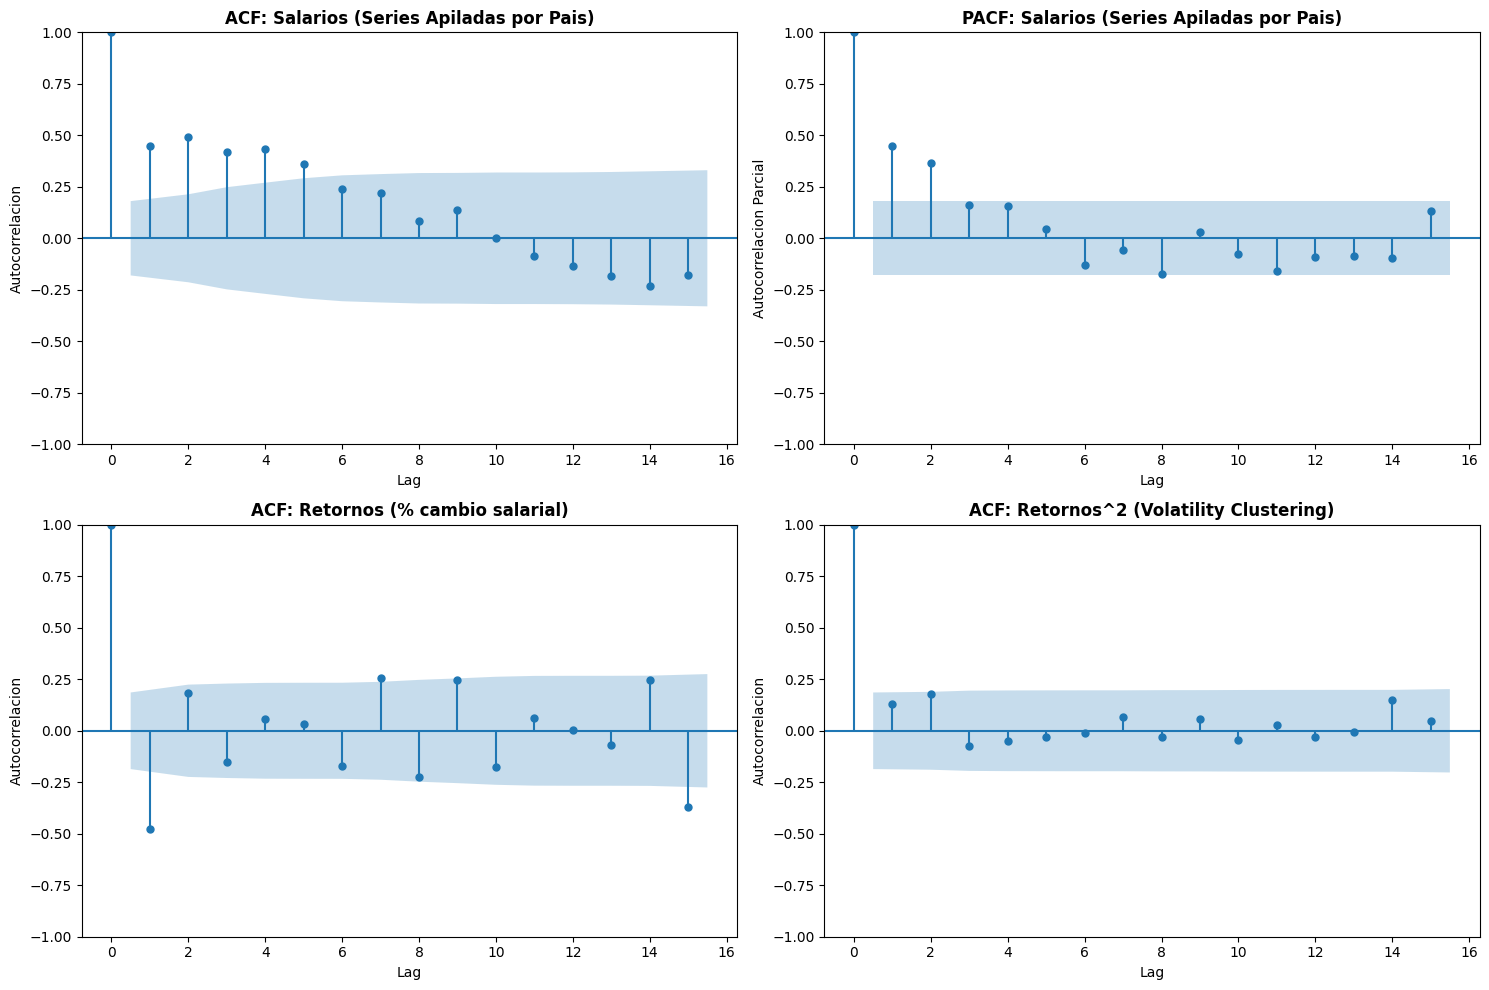


INTERPRETACION DE ACF - SERIES APILADAS

5.1 ACF DE SALARIOS (primeros 5 lags):
  Lag 1: 0.4484
  Lag 2: 0.4942
  Lag 3: 0.4172
  Lag 4: 0.4312
  Lag 5: 0.3600

5.2 ACF DE RETORNOS (primeros 5 lags):
  Lag 1: -0.4750
  Lag 2: 0.1846
  Lag 3: -0.1505
  Lag 4: 0.0562
  Lag 5: 0.0314

Bandas de confianza (95%): +/- 0.1860


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 5.1 ACF de Salarios apilados
plot_acf(stacked_salaries, lags=15, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lag', fontsize=10)
axes[0, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.2 PACF de Salarios apilados
plot_pacf(stacked_salaries, lags=15, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Lag', fontsize=10)
axes[0, 1].set_ylabel('Autocorrelacion Parcial', fontsize=10)

# 5.3 ACF de Retornos apilados
plot_acf(stacked_returns, lags=15, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF: Retornos (% cambio salarial)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag', fontsize=10)
axes[1, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.4 ACF de Retornos^2 (volatility clustering)
returns_squared = stacked_returns ** 2
plot_acf(returns_squared, lags=15, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF: Retornos^2 (Volatility Clustering)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelacion', fontsize=10)

plt.tight_layout()
plt.show()

# Calcular ACF manualmente
acf_salary = acf(stacked_salaries, nlags=10, fft=False)
acf_returns = acf(stacked_returns, nlags=10, fft=False)

print("\n" + "="*70)
print("INTERPRETACION DE ACF - SERIES APILADAS")
print("="*70)
print("\n5.1 ACF DE SALARIOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_salary[i]:.4f}")

print("\n5.2 ACF DE RETORNOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_returns[i]:.4f}")

n = len(stacked_returns)
conf_bound = 1.96 / np.sqrt(n)
print(f"\nBandas de confianza (95%): +/- {conf_bound:.4f}")

### STREAMGRAPH: EVOLUCION DE CATEGORIAS


Verificacion Streamgraph - Suma por cuatrimestre:
  Min: 100.00%
  Max: 100.00%
  Promedio: 100.00%
  OK: Todas las sumas son 100%


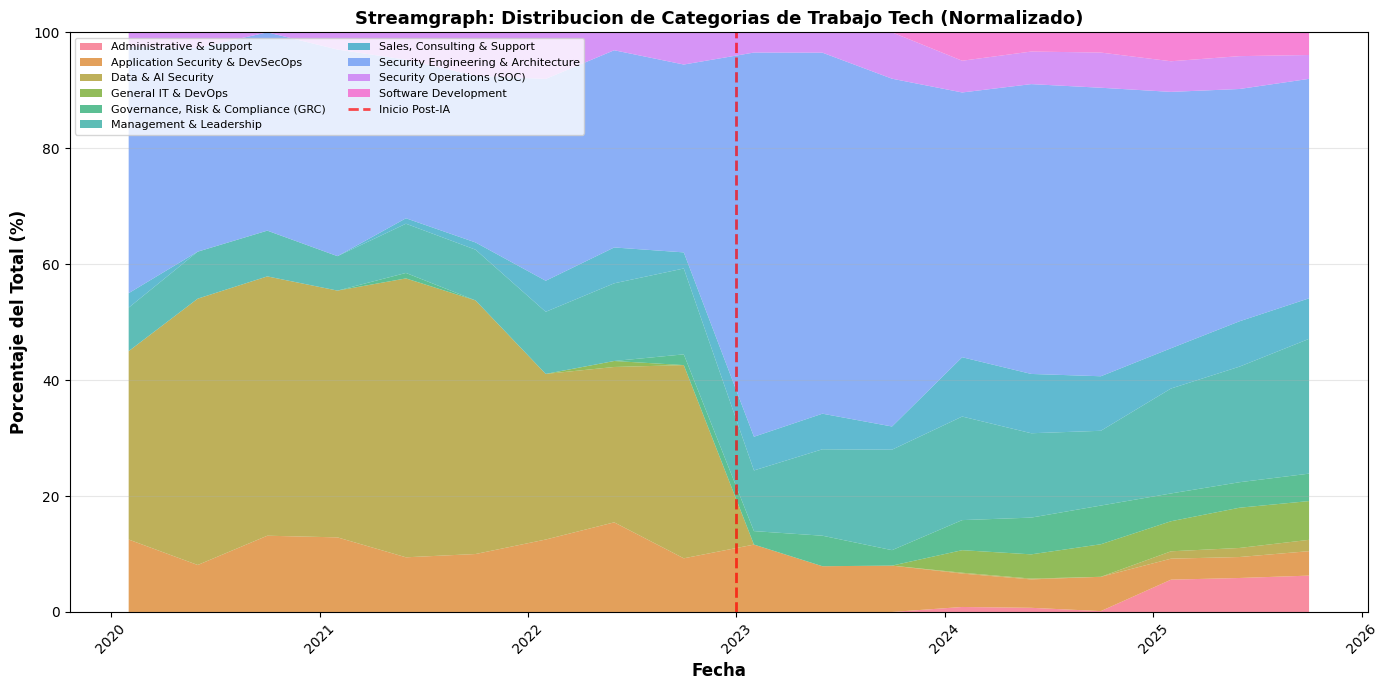

In [12]:
# CORRECCION 2: El area debe sumar al 100% en cada punto temporal

# Tomar top 10 categorias por volumen
top_categories = df.groupby('category').size().nlargest(10).index.tolist()
category_quarter_filtered = category_quarter[category_quarter['category'].isin(top_categories)]

# Pivot y convertir a porcentajes (suma 100% en cada cuatrimestre)
category_quarter_pivot = category_quarter_filtered.pivot(
    index='fecha_artificial', 
    columns='category', 
    values='count'
).fillna(0)

# Normalizar a porcentajes
category_quarter_pct = category_quarter_pivot.div(category_quarter_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

if len(category_quarter_pct.columns) > 0:
    colors_stream = sns.color_palette("husl", len(category_quarter_pct.columns))
    
    # Usar stackplot que garantiza que el area suma correctamente
    ax.stackplot(category_quarter_pct.index, 
                 *[category_quarter_pct[col] for col in category_quarter_pct.columns],
                 labels=category_quarter_pct.columns,
                 colors=colors_stream,
                 alpha=0.8,
                 baseline='zero')  # Asegura que inicie en 0
    
    ax.axvline(pd.Timestamp('2023-01-01'), color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label='Inicio Post-IA')
    ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax.set_ylabel('Porcentaje del Total (%)', fontsize=12, fontweight='bold')
    ax.set_title('Streamgraph: Distribucion de Categorias de Trabajo Tech (Normalizado)', 
                 fontsize=13, fontweight='bold')
    
    # Verificar que suma 100%
    total_check = category_quarter_pct.sum(axis=1)
    print(f"\nVerificacion Streamgraph - Suma por cuatrimestre:")
    print(f"  Min: {total_check.min():.2f}%")
    print(f"  Max: {total_check.max():.2f}%")
    print(f"  Promedio: {total_check.mean():.2f}%")
    
    if not np.allclose(total_check, 100, atol=0.1):
        print("  ADVERTENCIA: Las sumas no son exactamente 100%")
    else:
        print("  OK: Todas las sumas son 100%")
    
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)  # Forzar rango 0-100%
    plt.xticks(rotation=45)
    
else:
    ax.text(0.5, 0.5, 'No hay suficientes categorias para visualizar', 
            ha='center', va='center', fontsize=12)
    ax.set_title('Streamgraph: Evolucion de Categorias (sin datos suficientes)', fontsize=13)

plt.tight_layout()
plt.show()

### COMPARACION PRE-IA vs POST-IA

In [13]:
print("\n" + "="*70)
print("COMPARACION ESTADISTICA: PRE-IA vs POST-IA")
print("="*70)

pre_ia = df[df['ai_period'] == 'Pre-IA (2020-2022)']['salary_in_usd']
post_ia = df[df['ai_period'] == 'Post-IA (2023-2025)']['salary_in_usd']

t_stat, p_value = stats.ttest_ind(post_ia, pre_ia)

print(f"\n7.1 SALARIOS:")
print(f"Pre-IA:  Media = ${pre_ia.mean():,.2f}, Mediana = ${pre_ia.median():,.2f}, n = {len(pre_ia)}")
print(f"Post-IA: Media = ${post_ia.mean():,.2f}, Mediana = ${post_ia.median():,.2f}, n = {len(post_ia)}")
print(f"\nCambio porcentual: {((post_ia.mean() - pre_ia.mean()) / pre_ia.mean() * 100):.2f}%")
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4e}")
if p_value < 0.001:
    print("Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")


COMPARACION ESTADISTICA: PRE-IA vs POST-IA

7.1 SALARIOS:
Pre-IA:  Media = $81,192.76, Mediana = $69,336.00, n = 735
Post-IA: Media = $103,263.97, Mediana = $93,500.00, n = 5491

Cambio porcentual: 27.18%

T-test: t = 10.3934, p-value = 4.2613e-25
Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)

7.2 NUMERO DE POSICIONES:
Pre-IA:  735 posiciones
Post-IA: 5,491 posiciones
Crecimiento: 647.07%


### SLOPEGRAPH: COMPARACION 2020 vs 2025 POR PAIS

In [14]:
!!pip install adjustText

['Requirement already satisfied: adjustText in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.3.0)',
 'Requirement already satisfied: numpy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (2.3.3)',
 'Requirement already satisfied: matplotlib in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (3.10.6)',
 'Requirement already satisfied: scipy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (1.16.2)',
 'Requirement already satisfied: contourpy>=1.0.1 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (0.12.1)',
 'Requirement already

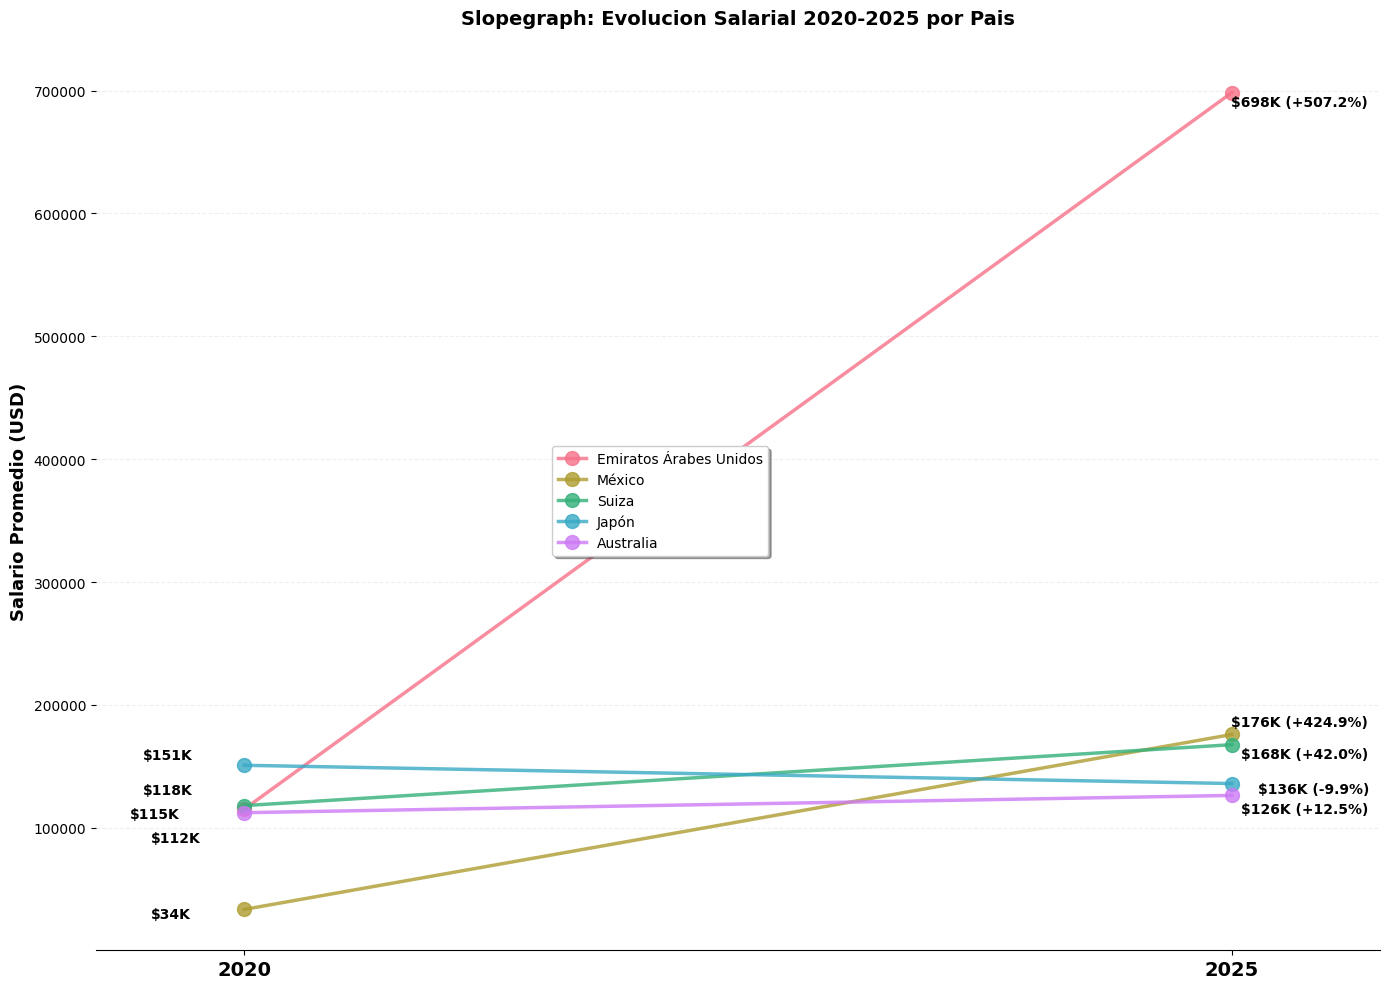


SLOPEGRAPH: TOP 5 PAISES
Emiratos Árabes Unidos: $115,000 -> $698,326 (+507.2%)
México: $33,511 -> $175,912 (+424.9%)
Suiza: $118,008 -> $167,613 (+42.0%)
Japón: $150,844 -> $135,981 (-9.9%)
Australia: $112,263 -> $126,305 (+12.5%)


In [15]:

from adjustText import adjust_text  # ### AÑADIDO 1: Importar la librería ###


# Obtener salarios por pais en 2020 y 2025
salary_2020 = df[df['work_year'] == 2020].groupby('employee_country_name')['salary_in_usd'].mean()
salary_2025 = df[df['work_year'] == 2025].groupby('employee_country_name')['salary_in_usd'].mean()

# Paises presentes en ambos años
common_countries = salary_2020.index.intersection(salary_2025.index)

if len(common_countries) >= 5:
    # Calcular crecimiento
    growth = ((salary_2025[common_countries] - salary_2020[common_countries]) / salary_2020[common_countries] * 100)
    
    # Top 5 paises por salario promedio en 2025
    top_countries = salary_2025[common_countries].nlargest(5).index
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Colores diferentes para cada linea
    colors = sns.color_palette("husl", len(top_countries))
    
    # ### AÑADIDO 2: Listas para guardar las etiquetas de texto ###
    texts_2020 = []
    texts_2025 = []
    
    for idx, country in enumerate(top_countries):
        y_2020 = salary_2020[country]
        y_2025 = salary_2025[country]
        change_pct = growth[country]
        
        # Linea con color unico
        ax.plot([0, 1], [y_2020, y_2025], 
                marker='o', markersize=10, linewidth=2.5, 
                alpha=0.8, color=colors[idx], label=country)
        
        # ### AÑADIDO 3: Guardar la etiqueta en la lista ###
        # Etiqueta 2020 (izquierda)
        texts_2020.append(
            ax.text(-0.05, y_2020, f"${y_2020/1000:.0f}K", 
                    ha='right', va='center', fontsize=10, fontweight='bold')
        )
        
        # ### AÑADIDO 4: Guardar la etiqueta en la lista ###
        # Etiqueta 2025 (derecha) con cambio porcentual
        texts_2025.append(
            ax.text(1.05, y_2025, f"${y_2025/1000:.0f}K ({change_pct:+.1f}%)", 
                    ha='left', va='center', fontsize=10, fontweight='bold')
        )
    
    ax.set_xlim(-0.15, 1.15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['2020', '2025'], fontsize=14, fontweight='bold')
    ax.set_ylabel('Salario Promedio (USD)', fontsize=13, fontweight='bold')
    ax.set_title('Slopegraph: Evolucion Salarial 2020-2025 por Pais', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Leyenda (se mantiene como en tu original)
    ax.legend(loc='center left', bbox_to_anchor=(0.35, 0.5), 
              fontsize=10, frameon=True, shadow=True)
    
    # ### AÑADIDO 5: Llamar a la función para ajustar el texto ###
    adjust_text(texts_2020)
    adjust_text(texts_2025)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("SLOPEGRAPH: TOP 5 PAISES") # Ajustado de 8 a 5 para que coincida con el código
    print("="*70)
    for country in top_countries:
        change = growth[country]
        print(f"{country}: ${salary_2020[country]:,.0f} -> ${salary_2025[country]:,.0f} ({change:+.1f}%)")
else:
    print("\nNOTA: No hay suficientes paises con datos en 2020 y 2025 para Slopegraph")

### HEATMAP: SALARIO PROMEDIO POR AÑO Y EXPERIENCE LEVEL

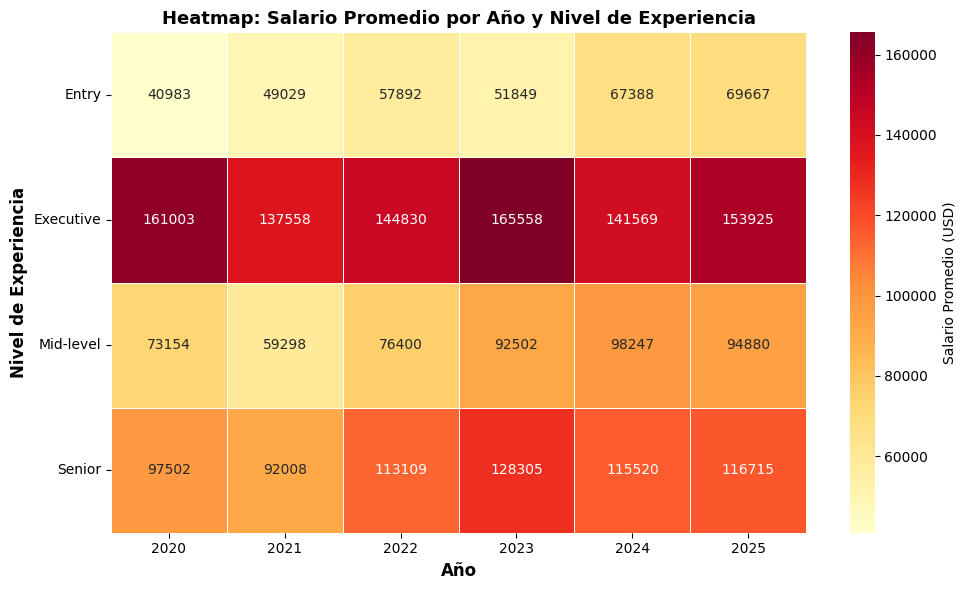


HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO
experience_level            EN             EX            MI             SE
work_year                                                                 
2020              40982.681818  161003.333333  73154.166667   97502.069767
2021              49029.136364  137557.625000  59297.596330   92007.871287
2022              57891.537037  144830.421053  76400.492958  113108.848214
2023              51848.961538  165557.888889  92502.494253  128305.098765
2024              67388.240741  141568.698413  98246.726008  115520.446231
2025              69666.773543  153924.780488  94880.066610  116715.424307


In [16]:
salary_year_exp = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(salary_year_exp.T, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Salario Promedio (USD)'}, ax=ax, linewidths=0.5)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Nivel de Experiencia', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Salario Promedio por Año y Nivel de Experiencia', 
             fontsize=13, fontweight='bold')

exp_level_labels = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
current_labels = ax.get_yticklabels()
new_labels = [exp_level_labels.get(label.get_text(), label.get_text()) for label in current_labels]
ax.set_yticklabels(new_labels, rotation=0)

plt.tight_layout()
plt.savefig('05_heatmap_salario_experiencia.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO")
print("="*70)
print(salary_year_exp)

### WATERFALL CHART: CAMBIO EN POSICIONES POR EXPERIENCE LEVEL

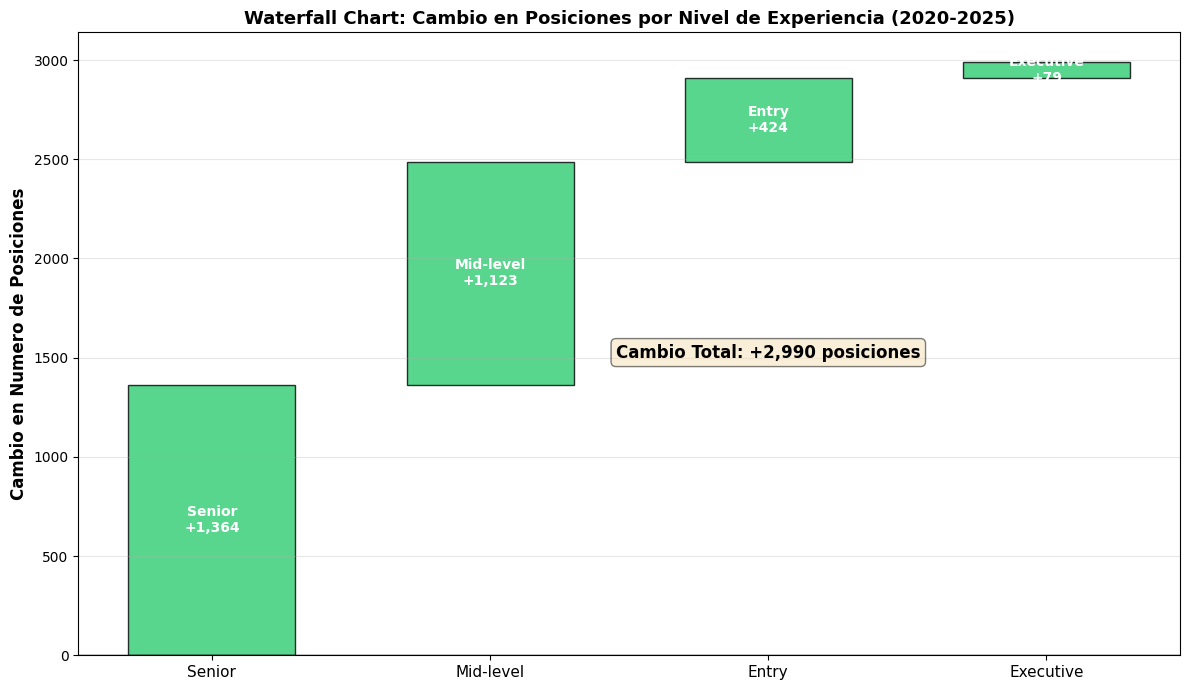


WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)
Senior: +1,364 posiciones
Mid-level: +1,123 posiciones
Entry: +424 posiciones
Executive: +79 posiciones

Cambio Total: +2,990 posiciones


In [17]:
exp_2020 = df[df['work_year'] == 2020]['experience_level'].value_counts()
exp_2025 = df[df['work_year'] == 2025]['experience_level'].value_counts()

all_levels = sorted(set(exp_2020.index) | set(exp_2025.index))
changes = {}
for level in all_levels:
    val_2020 = exp_2020.get(level, 0)
    val_2025 = exp_2025.get(level, 0)
    changes[level] = val_2025 - val_2020

changes_sorted = dict(sorted(changes.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 7))

cumulative = 0
x_pos = 0
colors_waterfall = []
positions = []
values_for_plot = []

for level, change in changes_sorted.items():
    if change > 0:
        colors_waterfall.append('#2ecc71')
    else:
        colors_waterfall.append('#e74c3c')
    
    ax.bar(x_pos, change, bottom=cumulative, width=0.6, 
           color=colors_waterfall[-1], alpha=0.8, edgecolor='black')
    
    label_name = exp_level_labels.get(level, level)
    ax.text(x_pos, cumulative + change/2, f"{label_name}\n{change:+,}", 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    positions.append(label_name)
    cumulative += change
    x_pos += 1

ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontsize=11)
ax.set_ylabel('Cambio en Numero de Posiciones', fontsize=12, fontweight='bold')
ax.set_title('Waterfall Chart: Cambio en Posiciones por Nivel de Experiencia (2020-2025)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

total_change = sum(changes.values())
ax.text(len(positions)/2, max(changes.values())*1.1, 
        f"Cambio Total: {total_change:+,} posiciones", 
        ha='center', fontsize=12, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)")
print("="*70)
for level, change in changes_sorted.items():
    label_name = exp_level_labels.get(level, level)
    print(f"{label_name}: {change:+,} posiciones")
print(f"\nCambio Total: {total_change:+,} posiciones")


### CROSS-CORRELATION FUNCTION (CCF) ENTRE PAISES

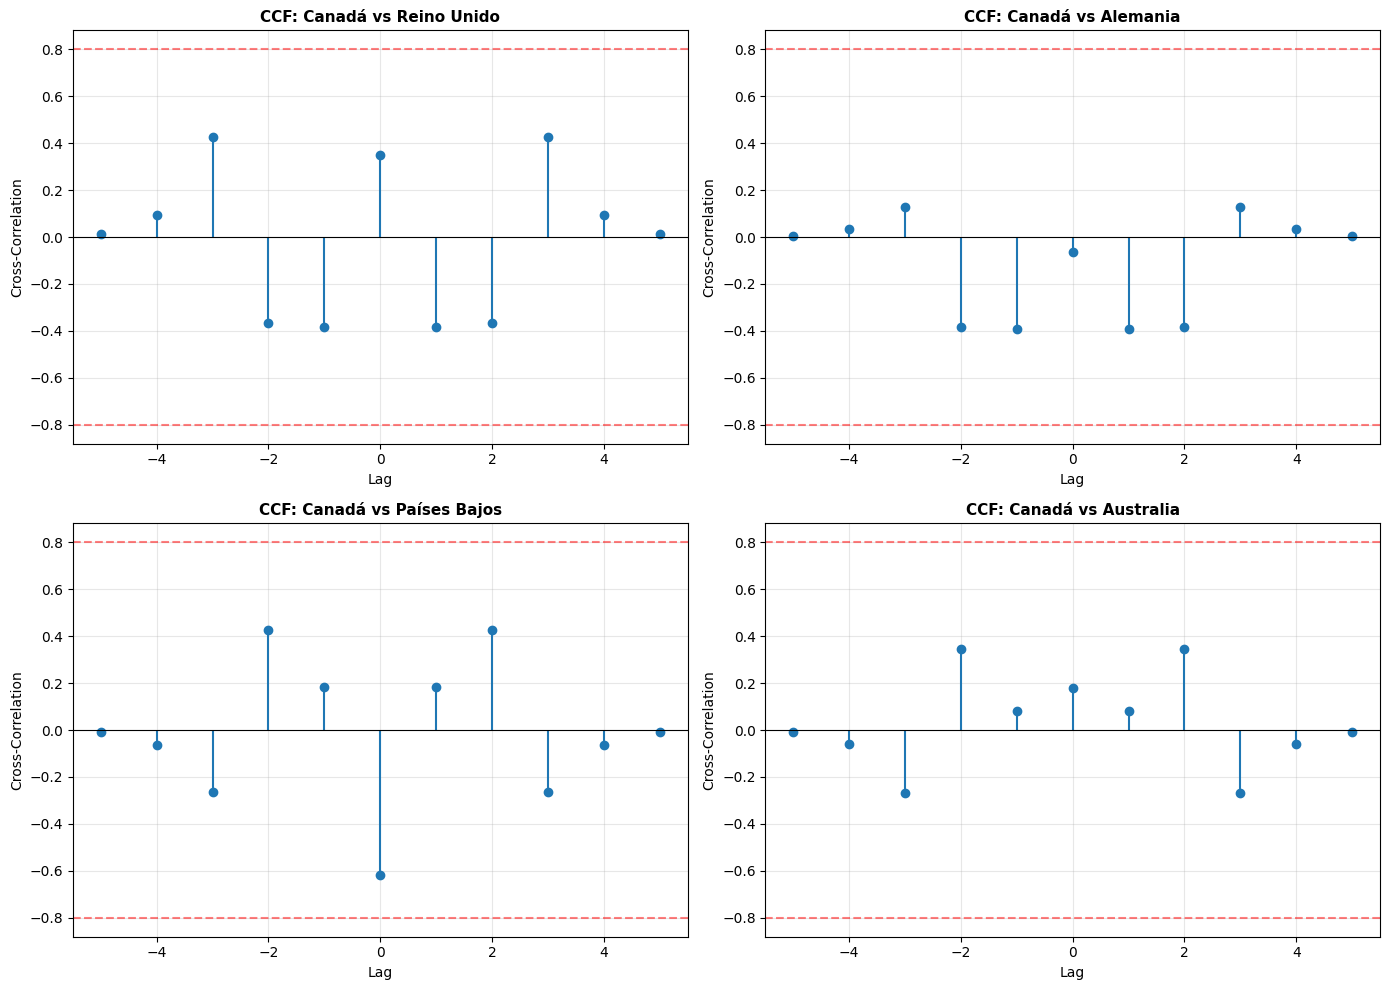


CROSS-CORRELATION FUNCTION: Canadá vs OTROS PAISES
Interpretacion:
- Lag negativo: Pais de referencia predice al otro pais
- Lag positivo: Otro pais predice al pais de referencia
- Lag 0: Correlacion contemporanea

7.2 NUMERO DE POSICIONES:
Pre-IA:  735 posiciones
Post-IA: 5,491 posiciones
Crecimiento: 647.07%


In [18]:
from statsmodels.tsa.stattools import ccf

# Construir country_year_salary si no existe: media salarial por pais y año
if 'country_year_salary' not in globals():
    country_year_salary = (
        df.groupby(['employee_country_name', 'work_year'])
          .agg(mean_salary=('salary_in_usd', 'mean'),
               count=('salary_in_usd', 'count'))
          .reset_index()
          .rename(columns={'employee_country_name': 'country', 'work_year': 'year'})
    )

# Seleccionar top 5 paises por volumen
top_5_countries = df['employee_country_name'].value_counts().head(5).index.tolist()

# Crear series temporales para cada pais
country_series = {}
for country in top_5_countries:
    country_data = country_year_salary[country_year_salary['country'] == country].sort_values('year')
    if len(country_data) >= 4:
        country_series[country] = country_data.set_index('year')['mean_salary']

if len(country_series) >= 2:
    reference_country = top_5_countries[0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    plot_idx = 0
    for i, country in enumerate(top_5_countries[1:5]):
        if country in country_series and reference_country in country_series:
            series1 = country_series[reference_country]
            series2 = country_series[country]
            
            common_years = series1.index.intersection(series2.index)
            if len(common_years) >= 4:
                s1 = series1[common_years].values
                s2 = series2[common_years].values
                
                ccf_values = ccf(s1, s2, adjusted=False)
                # ccf returns correlations for non-negative lags; create symmetric lags for plotting
                max_lag = len(ccf_values) - 1
                lags = np.arange(-max_lag, max_lag + 1)
                # build symmetric ccf array (lag negative -> ccf at positive lag of reversed order)
                ccf_sym = np.concatenate((ccf_values[:0:-1], ccf_values))
                
                mid = len(ccf_sym) // 2
                half = mid  # number of lags to show on each side
                axes[plot_idx].stem(lags[mid - half: mid + half + 1], ccf_sym[mid - half: mid + half + 1], 
                                   basefmt=' ', linefmt='C0-', markerfmt='C0o')
                
                conf_bound = 1.96 / np.sqrt(len(common_years))
                axes[plot_idx].axhline(conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(-conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(0, color='black', linewidth=0.8)
                
                axes[plot_idx].set_xlabel('Lag', fontsize=10)
                axes[plot_idx].set_ylabel('Cross-Correlation', fontsize=10)
                axes[plot_idx].set_title(f'CCF: {reference_country} vs {country}', 
                                        fontsize=11, fontweight='bold')
                axes[plot_idx].grid(True, alpha=0.3)
                
                plot_idx += 1
    
    for idx in range(plot_idx, 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print(f"CROSS-CORRELATION FUNCTION: {reference_country} vs OTROS PAISES")
    print("="*70)
    print("Interpretacion:")
    print("- Lag negativo: Pais de referencia predice al otro pais")
    print("- Lag positivo: Otro pais predice al pais de referencia")
    print("- Lag 0: Correlacion contemporanea")
else:
    print("\nNOTA: No hay suficientes paises con datos para CCF")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")


### ANALISIS ESPACIAL - MAPAS GEOGRAFICOS

In [19]:
!!pip install geopandas folium

['Requirement already satisfied: geopandas in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.1.1)',
 'Requirement already satisfied: folium in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Requirement already satisfied: numpy>=1.24 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.3)',
 'Requirement already satisfied: pyogrio>=0.7.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (0.11.1)',
 'Requirement already satisfied: packaging in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (25.0)',
 'Requirement already satisfied: pandas>=2.0.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.2)',
 'Requirement already satisfied: pyproj>=3.5.0 in c:\\users\\yuse

In [20]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
df['ai_period'] = df['work_year'].apply(lambda y: 'Pre-IA' if y <= 2022 else 'Post-IA')

print(f"\n📊 Dataset cargado: {df.shape[0]:,} registros")
print(f"   Columnas: {df.shape[1]}")
print(f"   Países únicos: {df['employee_country_name'].nunique()}")
print(f"   Departamentos: {df['department'].nunique()}")


📊 Dataset cargado: 65,117 registros
   Columnas: 23
   Países únicos: 95
   Departamentos: 11


### BALANCEO AUTOMÁTICO INTELIGENTE

In [22]:
print("\n" + "="*80)
print("BALANCEO AUTOMÁTICO POR SIMILITUD DE EMPLEOS")
print("="*80)

# Análisis de distribución por país
country_counts = df['employee_country_name'].value_counts()
dominant = country_counts.index[0]

# Estadísticas de distribución
q25, q50, q75, q90, q95 = country_counts.quantile([0.25, 0.5, 0.75, 0.90, 0.95])

print(f"\n📊 Distribución original:")
print(f"   • País dominante: {dominant} ({country_counts[dominant]:,} empleos)")
print(f"   • Percentil 95: {q95:.0f}")
print(f"   • Percentil 75: {q75:.0f}")
print(f"   • Mediana (P50): {q50:.0f}")
print(f"   • Percentil 25: {q25:.0f}")

# ESTRATEGIA: Submuestrear país dominante a 3x el P95 de otros países
# Esto mantiene su importancia pero permite comparación justa
otros_paises_p95 = country_counts[country_counts.index != dominant].quantile(0.95)
target_dominant = int(otros_paises_p95 * 3)

print(f"\n🎯 Estrategia de balanceo:")
print(f"   • P95 de otros países: {otros_paises_p95:.0f}")
print(f"   • Target para {dominant}: {target_dominant:,} (3x P95)")

# Aplicar balanceo
np.random.seed(42)
df_dominant = df[df['employee_country_name'] == dominant].sample(n=min(target_dominant, len(df[df['employee_country_name'] == dominant])), random_state=42)
df_others = df[df['employee_country_name'] != dominant]
df_balanced = pd.concat([df_dominant, df_others], ignore_index=True)

print(f"\n✅ Resultado del balanceo:")
print(f"   • {dominant}: {len(df_dominant):,} empleos")
print(f"   • Otros países: {len(df_others):,} empleos")
print(f"   • Total balanceado: {len(df_balanced):,} empleos")
print(f"   • Reducción: {(1 - len(df_balanced)/len(df))*100:.1f}%")


BALANCEO AUTOMÁTICO POR SIMILITUD DE EMPLEOS

📊 Distribución original:
   • País dominante: Estados Unidos (58,909 empleos)
   • Percentil 95: 300
   • Percentil 75: 24
   • Mediana (P50): 6
   • Percentil 25: 2

🎯 Estrategia de balanceo:
   • P95 de otros países: 214
   • Target para Estados Unidos: 642 (3x P95)

✅ Resultado del balanceo:
   • Estados Unidos: 642 empleos
   • Otros países: 6,208 empleos
   • Total balanceado: 6,850 empleos
   • Reducción: 89.5%


### CÓDIGOS ISO AUTOMÁTICOS (CON FUZZY MATCHING)

In [23]:
print("\n" + "="*80)
print("GENERANDO CÓDIGOS ISO AUTOMÁTICAMENTE")
print("="*80)

try:
    import pycountry
    from difflib import get_close_matches
    
    def get_iso3_code(country_name):
        """
        Convierte nombre de país a código ISO3 automáticamente.
        Usa fuzzy matching para nombres en español/inglés.
        """
        if pd.isna(country_name):
            return None
        
        # Diccionario de casos especiales (nombres en español y variaciones)
        special_cases = {
            # Nombres en español comunes
            'Estados Unidos': 'USA',
            'Reino Unido': 'GBR',
            'Países Bajos': 'NLD',
            'Corea del Sur': 'KOR',
            'República Checa': 'CZE',
            'Arabia Saudita': 'SAU',
            'España': 'ESP',
            'Bélgica': 'BEL',
            'Emiratos Árabes Unidos': 'ARE',
            'Irán': 'IRN',
            'Turquía': 'TUR',
            'Túnez': 'TUN',
            'Bolivia': 'BOL',
            'Taiwán': 'TWN',
            'Macedonia (ARYM)': 'MKD',
            # Variaciones adicionales comunes
            'Alemania': 'DEU',
            'Suiza': 'CHE',
            'Japón': 'JPN',
            'Grecia': 'GRC',
            'Dinamarca': 'DNK',
            'Suecia': 'SWE',
            'Noruega': 'NOR',
            'Finlandia': 'FIN',
            'Polonia': 'POL',
            'Austria': 'AUT',
            'Hungría': 'HUN',
            'Rumania': 'ROU',
            'Croacia': 'HRV'
        }
        
        # Revisar casos especiales primero
        if country_name in special_cases:
            return special_cases[country_name]
        
        # Intentar búsqueda directa por nombre
        try:
            country = pycountry.countries.get(name=country_name)
            if country:
                return country.alpha_3
        except:
            pass
        
        # Intentar búsqueda por nombre oficial
        try:
            country = pycountry.countries.get(official_name=country_name)
            if country:
                return country.alpha_3
        except:
            pass
        
        # Fuzzy matching: buscar país más cercano
        all_country_names = [c.name for c in pycountry.countries]
        matches = get_close_matches(country_name, all_country_names, n=1, cutoff=0.6)
        
        if matches:
            country = pycountry.countries.get(name=matches[0])
            return country.alpha_3
        
        return None
    
    # Generar mapeo automático para todos los países en el dataset
    unique_countries = df_balanced['employee_country_name'].unique()
    iso_map = {}
    
    print(f"\nGenerando códigos ISO3 para {len(unique_countries)} países...")
    not_found = []
    
    for country in unique_countries:
        iso_code = get_iso3_code(country)
        if iso_code:
            iso_map[country] = iso_code
        else:
            not_found.append(country)
    
    print(f"✓ Países mapeados exitosamente: {len(iso_map)}")
    if not_found:
        print(f"⚠️ Países sin código ISO (se excluirán de mapas): {not_found}")
    
except ImportError:
    print("⚠️ pycountry no disponible. Usando mapeo manual...")
    # Fallback: diccionario manual reducido (solo países comunes)
    iso_map = {
        'Estados Unidos': 'USA', 'Canadá': 'CAN', 'Reino Unido': 'GBR', 
        'Alemania': 'DEU', 'España': 'ESP', 'Francia': 'FRA', 'India': 'IND',
        'Países Bajos': 'NLD', 'Australia': 'AUS', 'Brasil': 'BRA', 
        'Portugal': 'PRT', 'Italia': 'ITA', 'Polonia': 'POL', 'Austria': 'AUT',
        'Suiza': 'CHE', 'México': 'MEX', 'Grecia': 'GRC', 'Suecia': 'SWE',
        'Noruega': 'NOR', 'Dinamarca': 'DNK', 'Finlandia': 'FIN', 'Irlanda': 'IRL',
        'Bélgica': 'BEL', 'Israel': 'ISR', 'Singapur': 'SGP', 'Japón': 'JPN',
        'Corea del Sur': 'KOR', 'China': 'CHN', 'Argentina': 'ARG'
    }



GENERANDO CÓDIGOS ISO AUTOMÁTICAMENTE

Generando códigos ISO3 para 95 países...
✓ Países mapeados exitosamente: 95


### CHOROPLETH MAP: DENSIDAD DE EMPLEOS

In [24]:
print("\n" + "="*80)
print("3.1.1 CHOROPLETH MAP: Densidad de Empleos por País")
print("="*80)

# Agregar por país
country_density = df_balanced.groupby('employee_country_name').agg({
    'salary_in_usd': ['count', 'mean', 'median'],
    'work_year': 'nunique',
    'department': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).reset_index()

country_density.columns = ['country', 'job_count', 'mean_salary', 'median_salary', 'years', 'top_dept']
country_density['iso'] = country_density['country'].map(iso_map)

# Filtrar países sin ISO (para mapas)
country_density_mapped = country_density[country_density['iso'].notna()].copy()

print(f"\n🔍 Verificación de datos para Choropleth 1:")
print(f"   • Total países: {len(country_density)}")
print(f"   • Países con ISO: {len(country_density_mapped)}")
print(f"   • Rango de empleos: {country_density_mapped['job_count'].min()} - {country_density_mapped['job_count'].max()}")
print(f"\n📊 Muestra de datos:")
print(country_density_mapped[['country', 'iso', 'job_count', 'mean_salary']].head(10))

# Verificar que hay datos
if len(country_density_mapped) == 0:
    print("❌ ERROR: No hay países con códigos ISO para mapear")
else:
    fig_choropleth1 = px.choropleth(
        country_density_mapped,
        locations='iso',
        locationmode='ISO-3',  # IMPORTANTE: especificar modo ISO-3
        color='job_count',
        hover_name='country',
        hover_data={
            'iso': False,
            'job_count': ':,',
            'mean_salary': ':$,.0f',
            'median_salary': ':$,.0f',
            'top_dept': True
        },
        color_continuous_scale='YlOrRd',
        title='<b>Choropleth Map: Densidad de Empleos Data Science por País</b>',
        labels={'job_count': 'Número de Empleos'}
    )
    
    fig_choropleth1.update_geos(
        projection_type="natural earth",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue",
        showcountries=True,
        countrycolor="white"
    )
    
    fig_choropleth1.update_layout(
        height=700,
        width=1200,
        font=dict(size=12),
        title_x=0.5,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    
    print(f"✓ Choropleth 1 generado con {len(country_density_mapped)} países")
    
    # MOSTRAR EL MAPA
    fig_choropleth1.show()
    print("   → Mapa abierto en navegador")

print(f"\n📊 Top 10 países por densidad:")
print(country_density_mapped.nlargest(10, 'job_count')[['country', 'job_count', 'mean_salary']])



3.1.1 CHOROPLETH MAP: Densidad de Empleos por País

🔍 Verificación de datos para Choropleth 1:
   • Total países: 95
   • Países con ISO: 95
   • Rango de empleos: 1 - 2132

📊 Muestra de datos:
          country  iso  job_count    mean_salary
0      Afganistán  AFG          3   76666.666667
1         Albania  ALB          2   50000.000000
2        Alemania  DEU        479  103321.281837
3  Arabia Saudita  SAU          1  100000.000000
4         Argelia  ARG          1  100000.000000
5       Argentina  ARG          8   57000.000000
6         Armenia  ARM          2   50000.000000
7       Australia  AUS        298  126744.600671
8         Austria  AUT        169   62113.899408
9      Azerbaiyán  AZE          2   50000.000000
✓ Choropleth 1 generado con 95 países


   → Mapa abierto en navegador

📊 Top 10 países por densidad:
           country  job_count    mean_salary
15          Canadá       2132  127999.055347
75     Reino Unido       1353   85852.600148
30  Estados Unidos        642  148649.962617
2         Alemania        479  103321.281837
71    Países Bajos        303   77677.207921
7        Australia        298  126744.600671
8          Austria        169   62113.899408
27      Eslovaquia        147   36984.795918
34         Francia        121   73073.859504
29          España         96   72378.125000


### CHOROPLETH MAP: CRECIMIENTO SALARIAL PRE vs POST-IA

In [25]:
print("\n" + "="*80)
print("3.1.2 CHOROPLETH MAP: Crecimiento Salarial Pre-IA vs Post-IA")
print("="*80)

# Calcular salarios por período
salary_by_period = df_balanced.groupby(['employee_country_name', 'ai_period']).agg({
    'salary_in_usd': ['mean', 'count']
}).reset_index()
salary_by_period.columns = ['country', 'period', 'mean_salary', 'count']

# Pivotar para comparar
salary_pivot = salary_by_period.pivot(
    index='country',
    columns='period',
    values='mean_salary'
).reset_index()

# Solo países con datos en AMBOS períodos
salary_pivot = salary_pivot.dropna(subset=['Pre-IA', 'Post-IA'])

# Calcular crecimiento
salary_pivot['growth_pct'] = ((salary_pivot['Post-IA'] - salary_pivot['Pre-IA']) / salary_pivot['Pre-IA'] * 100)
salary_pivot['growth_abs'] = salary_pivot['Post-IA'] - salary_pivot['Pre-IA']
salary_pivot['iso'] = salary_pivot['country'].map(iso_map)

# Filtrar países mapeables
salary_pivot_mapped = salary_pivot[salary_pivot['iso'].notna()].copy()

print(f"\n🔍 Verificación de datos para Choropleth 2:")
print(f"   • Países con ambos períodos: {len(salary_pivot)}")
print(f"   • Países con ISO: {len(salary_pivot_mapped)}")
print(f"   • Rango de crecimiento: {salary_pivot_mapped['growth_pct'].min():.1f}% - {salary_pivot_mapped['growth_pct'].max():.1f}%")
print(f"\n📊 Muestra de datos:")
print(salary_pivot_mapped[['country', 'iso', 'Pre-IA', 'Post-IA', 'growth_pct']].head(10))

if len(salary_pivot_mapped) == 0:
    print("❌ ERROR: No hay países con datos en ambos períodos")
else:
    fig_choropleth2 = px.choropleth(
        salary_pivot_mapped,
        locations='iso',
        locationmode='ISO-3',  # IMPORTANTE: especificar modo ISO-3
        color='growth_pct',
        hover_name='country',
        hover_data={
            'iso': False,
            'Pre-IA': ':$,.0f',
            'Post-IA': ':$,.0f',
            'growth_pct': ':.1f',
            'growth_abs': ':+$,.0f'
        },
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
        title='<b>Choropleth Map: Crecimiento Salarial Pre-IA (≤2022) vs Post-IA (≥2023)</b>',
        labels={'growth_pct': 'Crecimiento (%)'}
    )
    
    fig_choropleth2.update_geos(
        projection_type="natural earth",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue",
        showcountries=True,
        countrycolor="white"
    )
    
    fig_choropleth2.update_layout(
        height=700,
        width=1200,
        font=dict(size=12),
        title_x=0.5,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    
    print(f"✓ Choropleth 2 generado con {len(salary_pivot_mapped)} países")
    
    # MOSTRAR EL MAPA
    fig_choropleth2.show()
    print("   → Mapa abierto en navegador")

print(f"\n📈 Top 10 países por crecimiento:")
print(salary_pivot_mapped.nlargest(10, 'growth_pct')[['country', 'Pre-IA', 'Post-IA', 'growth_pct']])


3.1.2 CHOROPLETH MAP: Crecimiento Salarial Pre-IA vs Post-IA

🔍 Verificación de datos para Choropleth 2:
   • Países con ambos períodos: 58
   • Países con ISO: 58
   • Rango de crecimiento: -90.6% - 658.9%

📊 Muestra de datos:
period    country  iso         Pre-IA        Post-IA  growth_pct
2        Alemania  DEU   85670.313433  106191.706311   23.953914
5       Argentina  ARG   53000.000000   61000.000000   15.094340
7       Australia  AUS  127391.961538  126682.720588   -0.556739
8         Austria  AUT   71339.200000   61832.640244  -13.325857
12         Brasil  BRA   62499.411765   64242.500000    2.788967
13       Bulgaria  BGR  103773.500000  110334.666667    6.322584
14        Bélgica  BEL   70740.400000  127410.368421   80.109765
15         Canadá  CAN  115812.158879  128643.004938   11.079015
16          Chile  CHL   45019.000000   96500.000000  114.353939
18         Chipre  CHL   42026.000000   70833.000000   68.545662
✓ Choropleth 2 generado con 58 países


   → Mapa abierto en navegador

📈 Top 10 países por crecimiento:
period                 country         Pre-IA        Post-IA  growth_pct
65                      México   19862.666667  150744.928571  658.936003
88                     Turquía   23822.500000  152212.200000  538.943016
39                    Honduras   20000.000000  115000.000000  475.000000
21                  Costa Rica   20100.000000   89285.714286  344.207534
62                       Malta   28369.000000  101068.500000  256.263880
19                    Colombia   21844.000000   71000.000000  225.032045
26      Emiratos Árabes Unidos  118142.857143  369163.000000  212.471705
78                     Rumania   45878.000000  125666.500000  173.914512
58                  Luxemburgo   54374.000000  128860.500000  136.989186
33                   Finlandia   36773.000000   80078.272727  117.763774


### PROPORTIONAL SYMBOL MAP: Salario Promedio

In [26]:
print("\n" + "="*80)
print("3.1.4 PROPORTIONAL SYMBOL MAP: Salario Promedio por Ubicación")
print("="*80)

# Usar coordenadas reales del dataset
country_coords = df_balanced.groupby('employee_country_name').agg({
    'employee_latitude': 'first',
    'employee_longitude': 'first',
    'salary_in_usd': ['mean', 'count']
}).reset_index()

country_coords.columns = ['country', 'lat', 'lon', 'mean_salary', 'job_count']
country_coords = country_coords[country_coords['lat'].notna() & country_coords['lon'].notna()]

fig_symbols = px.scatter_geo(
    country_coords,
    lat='lat',
    lon='lon',
    size='mean_salary',
    color='mean_salary',
    hover_name='country',
    hover_data={
        'lat': False,
        'lon': False,
        'mean_salary': ':$,.0f',
        'job_count': ':,'
    },
    color_continuous_scale='Viridis',
    size_max=50,
    title='<b>Proportional Symbol Map: Salario Promedio (Tamaño = Salario)</b>',
    labels={'mean_salary': 'Salario Promedio'}
)

fig_symbols.update_geos(projection_type="natural earth")
fig_symbols.update_layout(height=600, font=dict(size=12), title_x=0.5)

print(f"✓ Países con coordenadas: {len(country_coords)}")

# MOSTRAR MAPA
fig_symbols.show()
print("   → Proportional Symbol Map abierto en navegador")


3.1.4 PROPORTIONAL SYMBOL MAP: Salario Promedio por Ubicación
✓ Países con coordenadas: 95


   → Proportional Symbol Map abierto en navegador


### POINT DISTRIBUTION MAP: Clustering por Departamento

In [27]:
print("\n" + "="*80)
print("3.1.5 POINT DISTRIBUTION MAP: Distribución con Clustering")
print("="*80)

# Muestra aleatoria para visualización (10% o máx 5000 puntos)
sample_size = min(5000, int(len(df_balanced) * 0.1))
df_sample = df_balanced.sample(n=sample_size, random_state=42)

# Filtrar puntos con coordenadas válidas
df_sample_mapped = df_sample[
    df_sample['employee_latitude'].notna() & 
    df_sample['employee_longitude'].notna()
].copy()

fig_points = px.scatter_geo(
    df_sample_mapped,
    lat='employee_latitude',
    lon='employee_longitude',
    color='department',
    hover_name='employee_country_name',
    hover_data={
        'employee_latitude': False,
        'employee_longitude': False,
        'salary_in_usd': ':$,.0f',
        'experience_level': True,
        'job_title': True
    },
    title=f'<b>Point Distribution Map: Distribución Geográfica de Empleos ({len(df_sample_mapped):,} puntos)</b>',
    opacity=0.6
)

fig_points.update_geos(projection_type="natural earth")
fig_points.update_layout(height=600, font=dict(size=11), title_x=0.5)

print(f"✓ Puntos mapeados: {len(df_sample_mapped):,}")
print(f"   Departamentos: {df_sample_mapped['department'].nunique()}")

# MOSTRAR MAPA
fig_points.show()
print("   → Point Distribution Map abierto en navegador")



3.1.5 POINT DISTRIBUTION MAP: Distribución con Clustering
✓ Puntos mapeados: 685
   Departamentos: 9


   → Point Distribution Map abierto en navegador


### CARTOGRAM: Impacto Económico (Treemap)

In [28]:
print("\n" + "="*80)
print("3.1.6 CARTOGRAM: Países por Impacto Económico Total")
print("="*80)

# Calcular impacto económico
country_density['economic_impact'] = country_density['job_count'] * country_density['mean_salary']
country_density['impact_billions'] = country_density['economic_impact'] / 1e9

# Para el cartogram, necesitamos países con coordenadas
cartogram_data = country_density.merge(
    country_coords[['country', 'lat', 'lon']], 
    on='country', 
    how='inner'
)

# Normalizar tamaños para visualización (raíz cuadrada para mejor proporción)
cartogram_data['bubble_size'] = np.sqrt(cartogram_data['economic_impact']) / 1000

print(f"✓ Países para cartogram: {len(cartogram_data)}")
print(f"\n📊 Top 10 países por impacto económico:")
print(cartogram_data.nlargest(10, 'economic_impact')[['country', 'job_count', 'mean_salary', 'impact_billions']])

# CARTOGRAM usando burbujas proporcionales en posición geográfica
fig_cartogram = go.Figure()

# Agregar mapa base
fig_cartogram.add_trace(go.Scattergeo(
    lon=cartogram_data['lon'],
    lat=cartogram_data['lat'],
    mode='markers+text',
    marker=dict(
        size=cartogram_data['bubble_size'],
        color=cartogram_data['mean_salary'],
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(
            title="Salario<br>Promedio<br>(USD)",
            x=1.02
        ),
        line=dict(width=1, color='white'),
        sizemode='diameter'
    ),
    text=cartogram_data['country'],
    textfont=dict(size=8, color='white', family='Arial Black'),
    textposition='middle center',
    hovertemplate='<b>%{text}</b><br>' +
                  'Empleos: %{customdata[0]:,}<br>' +
                  'Salario Promedio: $%{customdata[1]:,.0f}<br>' +
                  'Impacto Económico: $%{customdata[2]:.2f}B<br>' +
                  '<extra></extra>',
    customdata=cartogram_data[['job_count', 'mean_salary', 'impact_billions']].values,
    showlegend=False
))

fig_cartogram.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor='rgb(230, 230, 230)',
    coastlinecolor='rgb(180, 180, 180)',
    showocean=True,
    oceancolor='rgb(200, 220, 240)',
    showcountries=True,
    countrycolor='rgb(200, 200, 200)',
    showlakes=True,
    lakecolor='rgb(200, 220, 240)'
)

fig_cartogram.update_layout(
    title='<b>Cartogram: Países Redimensionados por Impacto Económico (Tamaño = Empleos × Salario)</b>',
    height=700,
    width=1200,
    font=dict(size=12),
    title_x=0.5,
    margin=dict(l=0, r=0, t=50, b=0)
)





3.1.6 CARTOGRAM: Países por Impacto Económico Total
✓ Países para cartogram: 95

📊 Top 10 países por impacto económico:
           country  job_count    mean_salary  impact_billions
15          Canadá       2132  127999.055347         0.272894
75     Reino Unido       1353   85852.600148         0.116159
30  Estados Unidos        642  148649.962617         0.095433
2         Alemania        479  103321.281837         0.049491
7        Australia        298  126744.600671         0.037770
71    Países Bajos        303   77677.207921         0.023536
8          Austria        169   62113.899408         0.010497
34         Francia        121   73073.859504         0.008842
45         Irlanda         77  101731.844156         0.007833
48          Italia         82   94481.902439         0.007748


# INTEGRACION ESPACIOTEMPORAL

In [29]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
df['ai_period'] = df['work_year'].apply(lambda y: 'Pre-IA' if y <= 2022 else 'Post-IA')

# Crear fechas artificiales con cuatrimestres
np.random.seed(42)
df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))
cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
df['fecha_artificial'] = pd.to_datetime(
    df['work_year'].astype(str) + '-' + df['mes_artificial'].astype(str) + '-01'
)

print(f"\n📊 Dataset: {df.shape[0]:,} registros")
print(f"   Rango temporal: {df['fecha_artificial'].min()} - {df['fecha_artificial'].max()}")
print(f"   Países: {df['employee_country_name'].nunique()}")


📊 Dataset: 65,117 registros
   Rango temporal: 2020-02-01 00:00:00 - 2025-10-01 00:00:00
   Países: 95


In [30]:

print("\n" + "="*80)
print("PREPARACIÓN DE DATOS ESPACIOTEMPORALES")
print("="*80)

# Filtrar países con coordenadas y datos en ambos períodos
country_both_periods = df.groupby(['employee_country_name', 'ai_period']).size().unstack(fill_value=0)
countries_valid = country_both_periods[(country_both_periods['Pre-IA'] > 0) & 
                                       (country_both_periods['Post-IA'] > 0)].index.tolist()

df_valid = df[df['employee_country_name'].isin(countries_valid)].copy()

# Agregar coordenadas
df_valid = df_valid[df_valid['employee_latitude'].notna() & 
                    df_valid['employee_longitude'].notna()]

print(f"\n✓ Países con datos Pre y Post-IA: {len(countries_valid)}")
print(f"✓ Registros válidos: {len(df_valid):,}")


PREPARACIÓN DE DATOS ESPACIOTEMPORALES

✓ Países con datos Pre y Post-IA: 58
✓ Registros válidos: 64,803


### EARLY ADOPTERS - Difusión Geográfica del Impacto IA

In [31]:
print("\n" + "="*80)
print("3.3.1 EARLY ADOPTERS: Difusión Geográfica del Impacto IA")
print("="*80)

# Calcular impacto IA por país
impact_by_country = df_valid.groupby(['employee_country_name', 'ai_period']).agg({
    'salary_in_usd': 'mean',
    'work_year': 'count',
    'employee_latitude': 'first',
    'employee_longitude': 'first'
}).reset_index()

impact_by_country.columns = ['country', 'period', 'mean_salary', 'job_count', 'lat', 'lon']

# Pivotar para calcular cambios
impact_pivot = impact_by_country.pivot(index='country', columns='period', values='mean_salary')
impact_pivot['salary_growth'] = ((impact_pivot['Post-IA'] - impact_pivot['Pre-IA']) / 
                                  impact_pivot['Pre-IA'] * 100)

# Agregar coordenadas y conteos
coords_data = impact_by_country.groupby('country')[['lat', 'lon']].first()
job_counts_post = impact_by_country[impact_by_country['period'] == 'Post-IA'][['country', 'job_count']]

impact_pivot = impact_pivot.merge(coords_data, left_index=True, right_index=True)
impact_pivot = impact_pivot.merge(job_counts_post, left_index=True, right_on='country')
impact_pivot = impact_pivot.set_index('country')

# Calcular "velocidad de adopción": % crecimiento + volumen post-IA
impact_pivot['adoption_speed'] = (impact_pivot['salary_growth'] * 0.5 + 
                                   impact_pivot['job_count'] / impact_pivot['job_count'].max() * 100 * 0.5)

# Clasificar países por velocidad de adopción
impact_pivot['adoption_category'] = pd.qcut(
    impact_pivot['adoption_speed'], 
    q=4, 
    labels=['Late Adopter', 'Moderate Adopter', 'Fast Adopter', 'Early Adopter']
)

print(f"\n📊 Clasificación de países por adopción IA:")
print(impact_pivot['adoption_category'].value_counts().sort_index())

print(f"\n🏆 Early Adopters (Top 10):")
early_adopters = impact_pivot.nlargest(10, 'adoption_speed')
print(early_adopters[['Pre-IA', 'Post-IA', 'salary_growth', 'job_count', 'adoption_speed', 'adoption_category']])

# VISUALIZACIÓN 1: Mapa de Early Adopters
fig_early = px.scatter_geo(
    impact_pivot.reset_index(),
    lat='lat',
    lon='lon',
    size='job_count',
    color='adoption_category',
    hover_name='country',
    hover_data={
        'lat': False,
        'lon': False,
        'Pre-IA': ':$,.0f',
        'Post-IA': ':$,.0f',
        'salary_growth': ':.1f%',
        'job_count': ':,',
        'adoption_speed': ':.1f'
    },
    color_discrete_map={
        'Early Adopter': '#00ff00',
        'Fast Adopter': '#90EE90',
        'Moderate Adopter': '#FFD700',
        'Late Adopter': '#FF6347'
    },
    size_max=50,
    title='<b>Mapa de Early Adopters: Difusión Geográfica del Impacto IA</b><br>' +
          '<sub>Tamaño = Empleos Post-IA | Color = Velocidad de Adopción</sub>'
)

fig_early.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    showcountries=True,
    countrycolor="white"
)

fig_early.update_layout(height=700, width=1200, font=dict(size=12))
fig_early.show()

print("\n✓ Mapa de Early Adopters generado")

# VISUALIZACIÓN 2: Timeline de adopción
timeline_data = df_valid.groupby(['fecha_artificial', 'employee_country_name']).agg({
    'salary_in_usd': 'mean'
}).reset_index()

# Asegurar que fecha_artificial es datetime
timeline_data['fecha_artificial'] = pd.to_datetime(timeline_data['fecha_artificial'])

# Filtrar top 10 early adopters para timeline
top10_countries = early_adopters.head(10).index.tolist() if not early_adopters.empty else []
timeline_top10 = timeline_data[timeline_data['employee_country_name'].isin(top10_countries)].copy()

if not timeline_top10.empty:
    fig_timeline = px.line(
        timeline_top10,
        x='fecha_artificial',
        y='salary_in_usd',
        color='employee_country_name',
        title='<b>Timeline de Adopción IA: Evolución Salarial de Early Adopters</b>',
        labels={
            'fecha_artificial': 'Fecha',
            'salary_in_usd': 'Salario Promedio (USD)',
            'employee_country_name': 'País'
        }
    )

    # Agregar línea vertical en 2023 (inicio era Post-IA)
    # Convertir a timestamp numérico para evitar el error
    vline_date = pd.Timestamp('2023-01-01')
    
    # Usar add_shape en lugar de add_vline para mayor control
    fig_timeline.add_shape(
        type="line",
        x0=vline_date,
        x1=vline_date,
        y0=0,
        y1=1,
        yref="paper",
        line=dict(color="red", width=2, dash="dash")
    )
    
    # Agregar anotación manual
    fig_timeline.add_annotation(
        x=vline_date,
        y=1,
        yref="paper",
        text="Inicio Post-IA",
        showarrow=False,
        yanchor="bottom",
        font=dict(color="red", size=12)
    )

    fig_timeline.update_layout(height=600, width=1200, hovermode='x unified')
    fig_timeline.show()
    
    print("\n✓ Timeline de Early Adopters generado")
else:
    print("\n⚠️ No hay datos suficientes para generar el timeline de Early Adopters.")


3.3.1 EARLY ADOPTERS: Difusión Geográfica del Impacto IA

📊 Clasificación de países por adopción IA:
adoption_category
Late Adopter        15
Moderate Adopter    14
Fast Adopter        14
Early Adopter       15
Name: count, dtype: int64

🏆 Early Adopters (Top 10):
                               Pre-IA        Post-IA  salary_growth  \
country                                                               
México                   19862.666667  150744.928571     658.936003   
Turquía                  23822.500000  152212.200000     538.943016   
Honduras                 20000.000000  115000.000000     475.000000   
Costa Rica               20100.000000   89285.714286     344.207534   
Malta                    28369.000000  101068.500000     256.263880   
Colombia                 21844.000000   71000.000000     225.032045   
Emiratos Árabes Unidos  118142.857143  369163.000000     212.471705   
Rumania                  45878.000000  125666.500000     173.914512   
Luxemburgo              


✓ Mapa de Early Adopters generado



✓ Timeline de Early Adopters generado


### PROXIMIDAD GEOGRÁFICA vs SIMILITUD SALARIAL

In [39]:
print("\n" + "="*80)
print("3.3.3 PROXIMIDAD GEOGRÁFICA vs SIMILITUD EN EVOLUCIÓN SALARIAL")
print("="*80)

# Preparar datos por país
country_summary = df_valid.groupby('employee_country_name').agg({
    'employee_latitude': 'first',
    'employee_longitude': 'first',
    'salary_in_usd': 'mean'
}).reset_index()

country_summary.columns = ['country', 'lat', 'lon', 'mean_salary']

# Calcular matriz de distancias geográficas (haversine)
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """Calcular distancia en km entre dos puntos"""
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    km = 6371 * c
    return km

# Crear matriz de distancias
n_countries = len(country_summary)
geo_distance_matrix = np.zeros((n_countries, n_countries))

for i in range(n_countries):
    for j in range(n_countries):
        if i != j:
            geo_distance_matrix[i, j] = haversine(
                country_summary.iloc[i]['lon'], country_summary.iloc[i]['lat'],
                country_summary.iloc[j]['lon'], country_summary.iloc[j]['lat']
            )

geo_distance_df = pd.DataFrame(
    geo_distance_matrix,
    index=country_summary['country'],
    columns=country_summary['country']
)

# Calcular similitud en evolución salarial
# Usar series temporales de países comunes
common_countries = list(set(country_summary['country']) & set(valid_countries_ts))
print(f"\n✓ Países con datos geográficos y temporales: {len(common_countries)}")

# Matriz de similitud salarial (correlación de series temporales)
salary_similarity_matrix = pivot_returns_valid[common_countries].corr()

# Extraer distancias geográficas para países comunes
geo_distance_common = geo_distance_df.loc[common_countries, common_countries]

# Crear pares para análisis
pairs_data = []
for i, country1 in enumerate(common_countries):
    for j, country2 in enumerate(common_countries):
        if i < j:  # Evitar duplicados
            pairs_data.append({
                'country1': country1,
                'country2': country2,
                'geo_distance': geo_distance_common.loc[country1, country2],
                'salary_similarity': salary_similarity_matrix.loc[country1, country2]
            })

pairs_df = pd.DataFrame(pairs_data)
pairs_df = pairs_df[pairs_df['geo_distance'] > 0]  # Filtrar país consigo mismo

# Calcular correlación: ¿Menor distancia → Mayor similitud?
corr_geo_salary = stats.pearsonr(pairs_df['geo_distance'], pairs_df['salary_similarity'])

print(f"\n📊 Correlación: Distancia Geográfica vs Similitud Salarial")
print(f"   Pearson r = {corr_geo_salary[0]:.3f}")
print(f"   p-value = {corr_geo_salary[1]:.4f}")
print(f"   Interpretación: {'✅ La proximidad geográfica SÍ predice similitud salarial' if corr_geo_salary[1] < 0.05 and corr_geo_salary[0] < 0 else '❌ No hay relación significativa'}")

# VISUALIZACIÓN: Scatter proximidad vs similitud
fig_proximity = px.scatter(
    pairs_df,
    x='geo_distance',
    y='salary_similarity',
    hover_data=['country1', 'country2'],
    labels={
        'geo_distance': 'Distancia Geográfica (km)',
        'salary_similarity': 'Similitud en Evolución Salarial (Correlación)'
    },
    title=f'<b>Proximidad Geográfica vs Similitud Salarial</b><br>' +
          f'<sub>Pearson r={corr_geo_salary[0]:.3f}, p={corr_geo_salary[1]:.4f}</sub>',
    trendline='ols',
    trendline_color_override='red'
)

fig_proximity.update_layout(height=600, width=1000)
fig_proximity.show()

print("\n✓ Scatter de proximidad geográfica generado")

# VISUALIZACIÓN ADICIONAL: Network de países similares
print("\n📊 Identificando clusters geográfico-salariales...")

# Encontrar pares con alta similitud salarial (>0.6)
similar_pairs = pairs_df[pairs_df['salary_similarity'] > 0.6].copy()

print(f"\n✓ Pares de países con alta similitud salarial (>0.6): {len(similar_pairs)}")
print(similar_pairs.nlargest(10, 'salary_similarity')[['country1', 'country2', 'geo_distance', 'salary_similarity']])

# Network graph de similitud
import networkx as nx

G = nx.Graph()
for _, row in similar_pairs.iterrows():
    G.add_edge(row['country1'], row['country2'], weight=row['salary_similarity'])

# Obtener posiciones de países
pos = {country: (row['lon'], row['lat']) 
       for country, row in country_summary[country_summary['country'].isin(common_countries)].set_index('country').iterrows()}

# VISUALIZACIÓN MEJORADA: Network con líneas coloreadas y grosor variable
fig_network = go.Figure()

# Agregar líneas con grosor proporcional a la similitud
edge_colors = []
edge_widths = []
edge_texts = []

for edge in G.edges(data=True):
    if edge[0] in pos and edge[1] in pos:
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        weight = edge[2]['weight']
        
        # Color según intensidad de correlación
        if weight > 0.8:
            color = 'rgba(0, 255, 0, 0.7)'  # Verde fuerte
            width = 3
        elif weight > 0.7:
            color = 'rgba(144, 238, 144, 0.6)'  # Verde claro
            width = 2
        else:
            color = 'rgba(255, 215, 0, 0.5)'  # Amarillo
            width = 1
        
        fig_network.add_trace(go.Scattergeo(
            lon=[x0, x1],
            lat=[y0, y1],
            mode='lines',
            line=dict(width=width, color=color),
            hoverinfo='text',
            hovertext=f'{edge[0]} ↔ {edge[1]}<br>Correlación: {weight:.3f}',
            showlegend=False
        ))

# Agregar nodos (países) con tamaño proporcional al número de conexiones
node_degrees = dict(G.degree())
node_sizes = [node_degrees.get(node, 1) * 5 for node in G.nodes() if node in pos]

node_trace = go.Scattergeo(
    lon=[pos[node][0] for node in G.nodes() if node in pos],
    lat=[pos[node][1] for node in G.nodes() if node in pos],
    text=[f"{node}<br>Conexiones: {node_degrees.get(node, 0)}" for node in G.nodes() if node in pos],
    mode='markers+text',
    marker=dict(
        size=node_sizes,
        color='red',
        line=dict(width=2, color='white'),
        sizemode='diameter'
    ),
    textposition='top center',
    textfont=dict(size=9, color='black', family='Arial Black'),
    hoverinfo='text',
    showlegend=False
)

fig_network.add_trace(node_trace)

fig_network.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    showcountries=True,
    countrycolor="rgb(200, 200, 200)",
    showocean=True,
    oceancolor="lightblue",
    showlakes=True,
    lakecolor="lightblue"
)

# Agregar leyenda manual
fig_network.add_annotation(
    x=0.02, y=0.98,
    xref='paper', yref='paper',
    text='<b>Grosor de línea:</b><br>' +
         '━━━ Correlación > 0.8<br>' +
         '━━ Correlación 0.7-0.8<br>' +
         '━ Correlación 0.6-0.7',
    showarrow=False,
    bgcolor='white',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=10),
    align='left',
    xanchor='left',
    yanchor='top'
)

fig_network.update_layout(
    title='<b>Red de Similitud Salarial: Países con Evolución Correlacionada (r >0.6)</b><br>' +
          '<sub>Grosor de línea = Fuerza de correlación | Tamaño de nodo = Número de conexiones</sub>',
    height=700,
    width=1200,
    showlegend=False,
    margin=dict(l=0, r=0, t=80, b=0)
)

fig_network.show()

print("\n✓ Network de similitud salarial generado")

# VISUALIZACIÓN ADICIONAL: Heatmap de correlación (más informativo)
print("\n📊 Generando heatmap de correlación mejorado...")

# Usar top 15 países por número de conexiones
top_connected = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:15]
top_connected_countries = [c[0] for c in top_connected]

# Filtrar matriz de similitud
similarity_matrix_filtered = salary_similarity_matrix.loc[
    top_connected_countries, 
    top_connected_countries
]

fig_heatmap_corr = go.Figure(data=go.Heatmap(
    z=similarity_matrix_filtered.values,
    x=similarity_matrix_filtered.columns,
    y=similarity_matrix_filtered.index,
    colorscale='RdYlGn',
    zmid=0,
    zmin=-1,
    zmax=1,
    text=similarity_matrix_filtered.values.round(2),
    texttemplate='%{text}',
    textfont={"size": 9},
    colorbar=dict(title="Correlación<br>Temporal")
))

fig_heatmap_corr.update_layout(
    title='<b>Heatmap: Correlación Temporal entre Países (Top 15 más conectados)</b><br>' +
          '<sub>Verde = Evolución similar | Rojo = Evolución opuesta</sub>',
    xaxis_title='País',
    yaxis_title='País',
    height=800,
    width=900,
    xaxis={'side': 'bottom', 'tickangle': 45},
    yaxis={'side': 'left'}
)

fig_heatmap_corr.show()

print("\n✓ Heatmap de correlación generado")

# Análisis de clusters
print("\n📊 Identificando clusters regionales...")

# Países con más de 3 conexiones = hubs
hubs = [country for country, degree in node_degrees.items() if degree > 3]
print(f"\n🏆 Países HUB (>3 conexiones): {hubs}")

# Bloques regionales detectados
print(f"\n🌍 Bloques regionales detectados:")
components = list(nx.connected_components(G))
for i, component in enumerate(components, 1):
    if len(component) > 2:
        print(f"   Cluster {i} ({len(component)} países): {', '.join(sorted(component))}")


3.3.3 PROXIMIDAD GEOGRÁFICA vs SIMILITUD EN EVOLUCIÓN SALARIAL

✓ Países con datos geográficos y temporales: 22

📊 Correlación: Distancia Geográfica vs Similitud Salarial
   Pearson r = 0.054
   p-value = 0.4172
   Interpretación: ❌ No hay relación significativa



✓ Scatter de proximidad geográfica generado

📊 Identificando clusters geográfico-salariales...

✓ Pares de países con alta similitud salarial (>0.6): 73
           country1     country2  geo_distance  salary_similarity
174    Países Bajos     Alemania    371.812180           0.999996
226          Italia     Alemania   1045.902080           0.999806
103   Nueva Zelanda        Suiza  18761.747573           0.999775
172    Países Bajos       Italia   1265.830860           0.999749
180         Polonia        India   6165.674387           0.999507
178         Polonia        Suiza    971.343603           0.998772
44   Estados Unidos    Australia  15184.483973           0.998306
148          Canadá  Reino Unido   5807.429032           0.997892
100   Nueva Zelanda      Polonia  17804.376407           0.997496
112       Australia       Canadá  14151.620462           0.996763



✓ Network de similitud salarial generado

📊 Generando heatmap de correlación mejorado...



✓ Heatmap de correlación generado

📊 Identificando clusters regionales...

🏆 Países HUB (>3 conexiones): ['Brasil', 'Portugal', 'Grecia', 'Estados Unidos', 'Japón', 'Australia', 'Canadá', 'Irlanda', 'Austria', 'Reino Unido', 'Nueva Zelanda', 'Países Bajos', 'Polonia', 'Suiza', 'España', 'India', 'Italia', 'Alemania', 'México']

🌍 Bloques regionales detectados:
   Cluster 1 (22 países): Alemania, Australia, Austria, Brasil, Bélgica, Canadá, España, Estados Unidos, Francia, Grecia, India, Irlanda, Italia, Japón, México, Nueva Zelanda, Países Bajos, Polonia, Portugal, Reino Unido, Singapur, Suiza
